# IT Incident SLA Breach Prediction

Predicting which IT support tickets will miss their resolution target, using only the
information available at the moment the ticket is created.

**The problem.** A service desk usually discovers an SLA breach after it has happened.
By then the user has already waited too long and the monthly SLA report is already damaged.
If breaches can be flagged at intake, the desk can escalate or add a responder while the
outcome is still changeable.

**The data.** UCI *Incident Management Process Enriched Event Log* — anonymised ServiceNow
audit records from an IT company, 2016. Roughly 141,700 event rows covering 24,900 incidents
across 36 attributes.
[Dataset page](https://archive.ics.uci.edu/dataset/498/incident+management+process+enriched+event+log)

**The constraint that shapes everything below.** The dataset contains many fields that only
exist because a ticket already finished. Using them produces impressive scores and a useless
model. Section 5 audits every column against a single test and throws out anything the
service desk could not have read at minute zero.

Runs on Google Colab with no local setup.

## 1. Environment

In [1]:
# Colab already has pandas, numpy, sklearn, matplotlib and seaborn.
# ucimlrepo is the fallback data loader in Section 2.
!pip install -q ucimlrepo

In [2]:
import os
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, classification_report,
                             confusion_matrix, precision_recall_curve,
                             roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')

os.makedirs('plots', exist_ok=True)   # savefig fails without this on a fresh Colab VM

SEED = 42
print(f'pandas {pd.__version__} | numpy {np.__version__}')

pandas 2.2.3 | numpy 2.1.3


## 2. Loading the Data

Three routes, in order of convenience. Run **Option A** first; fall back if it fails.

In [3]:
# Option A — download the archive directly.
# Verify this URL against the dataset page if it 404s; UCI occasionally changes the path.
URL = ('https://archive.ics.uci.edu/static/public/498/'
       'incident+management+process+enriched+event+log.zip')
ZIP_PATH = 'incident_log.zip'

try:
    urllib.request.urlretrieve(URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH) as z:
        print('Files in archive:', z.namelist())
        z.extractall('.')
    print('Downloaded and extracted.')
except Exception as e:
    print(f'Direct download failed: {e}\nUse Option B or C below.')

Files in archive: ['incident_event_log.csv']
Downloaded and extracted.


In [4]:
# Option B — pull it through the UCI package instead.
# from ucimlrepo import fetch_ucirepo
# repo = fetch_ucirepo(id=498)
# df = pd.concat([repo.data.features, repo.data.targets], axis=1)

# Option C — upload the CSV by hand.
# from google.colab import files
# files.upload()

In [5]:
# The '?' marker and day-first dates are both easy to miss and both corrupt the
# analysis silently, so they are handled at load time.
CSV_PATH = 'incident_event_log.csv'   # adjust to whatever Option A printed

df = pd.read_csv(CSV_PATH, na_values='?', low_memory=False)

print(f'Rows    : {len(df):,}')
print(f'Columns : {df.shape[1]}')
df.head(3)

Rows    : 141,712
Columns : 36


,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 21,29/2/2016 01:23,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 642,29/2/2016 08:53,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 804,29/2/2016 11:29,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00


In [6]:
# Column names below were taken from the dataset documentation rather than the file.
# Reconcile them once, here, instead of hitting a KeyError twenty cells later.
EXPECTED = [
    'number', 'incident_state', 'active', 'reassignment_count', 'reopen_count',
    'sys_mod_count', 'made_sla', 'caller_id', 'opened_by', 'opened_at',
    'sys_created_by', 'sys_created_at', 'sys_updated_by', 'sys_updated_at',
    'contact_type', 'location', 'category', 'subcategory', 'u_symptom', 'cmdb_ci',
    'impact', 'urgency', 'priority', 'assignment_group', 'assigned_to', 'knowledge',
    'u_priority_confirmation', 'notify', 'problem_id', 'rfc', 'vendor', 'caused_by',
    'closed_code', 'resolved_by', 'resolved_at', 'closed_at',
]

missing = [c for c in EXPECTED if c not in df.columns]
extra = [c for c in df.columns if c not in EXPECTED]
print('Missing :', missing or 'none')
print('Extra   :', extra or 'none')

Missing : none
Extra   : none


In [7]:
DATE_COLS = ['opened_at', 'sys_created_at', 'sys_updated_at', 'resolved_at', 'closed_at']

for col in DATE_COLS:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

# Sanity check the parse. Expect everything inside 2016. A min in 1970 or a max in
# 2050 means dayfirst is wrong for this copy of the file.
print(df[DATE_COLS].agg(['min', 'max', 'count']).T)

                                min                  max   count
opened_at       2016-02-29 01:16:00  2017-02-16 14:17:00  141712
sys_created_at  2016-02-29 01:23:00  2017-01-27 16:59:00   88636
sys_updated_at  2016-02-29 01:23:00  2017-02-18 15:00:00  141712
resolved_at     2016-02-29 09:04:00  2017-02-17 00:47:00  138571
closed_at       2016-02-29 17:47:00  2017-02-18 15:00:00  141712


## 3. What Kind of Table Is This?

Not a ticket table. Each incident appears once per state change, so a long-running ticket
that bounced between four teams contributes far more rows than one resolved on first
contact. Training on the raw file would weight tickets by how much trouble they caused and
would mix intake information with post-resolution information inside the same row.

In [8]:
events_per_incident = df.groupby('number').size()

print(f'Incidents    : {df["number"].nunique():,}')
print(f'Event rows   : {len(df):,}')
print(f'Events each  : mean {events_per_incident.mean():.1f}, '
      f'median {events_per_incident.median():.0f}, max {events_per_incident.max()}')
print()
print(df['incident_state'].value_counts(dropna=False))

Incidents    : 24,918
Event rows   : 141,712
Events each  : mean 5.7, median 5, max 58

incident_state
Active                38716
New                   36407
Resolved              25751
Closed                24985
Awaiting User Info    14642
Awaiting Vendor         707
Awaiting Problem        461
Awaiting Evidence        38
-100                      5
Name: count, dtype: int64


In [9]:
# Read one busy incident end to end. This is the cell that makes the collapse
# rule in Section 4 feel obvious rather than arbitrary.
busiest = events_per_incident.idxmax()

(df[df['number'] == busiest]
   .sort_values('sys_updated_at')
   [['number', 'incident_state', 'sys_updated_at', 'assignment_group',
     'reassignment_count', 'priority', 'made_sla']])

,number,incident_state,sys_updated_at,assignment_group,reassignment_count,priority,made_sla
81418,INC0019396,New,2016-04-14 20:42:00,Group 66,0,3 - Moderate,True
81419,INC0019396,New,2016-04-14 21:08:00,Group 66,0,3 - Moderate,True
81420,INC0019396,Resolved,2016-04-15 09:20:00,Group 66,0,3 - Moderate,True
81421,INC0019396,Active,2016-04-15 15:21:00,Group 66,0,3 - Moderate,True
81422,INC0019396,Active,2016-04-15 15:21:00,Group 66,0,3 - Moderate,True
81423,INC0019396,Active,2016-04-15 20:30:00,Group 66,0,3 - Moderate,True
81424,INC0019396,Active,2016-04-15 20:30:00,Group 66,0,3 - Moderate,True
81425,INC0019396,Active,2016-04-16 23:43:00,Group 66,0,3 - Moderate,True
81426,INC0019396,Active,2016-04-16 23:43:00,Group 66,0,3 - Moderate,True
81427,INC0019396,Active,2016-04-20 11:12:00,Group 54,1,3 - Moderate,True


## 4. One Row Per Incident

| Taken from | Used for | Reasoning |
|---|---|---|
| **First** event, by `sys_updated_at` | features | closest available snapshot to what the desk knew at intake |
| **Last** event, by `sys_updated_at` | label and outcome fields | the settled result |

The first audit record is written moments after the ticket opens, not at the instant it
opens, so this is an approximation. Section 5 states that plainly rather than glossing it.

In [10]:
df = df.sort_values(['number', 'sys_updated_at']).reset_index(drop=True)

intake = df.groupby('number', as_index=False).first()
final = df.groupby('number', as_index=False).last()

OUTCOME = ['number', 'made_sla', 'opened_at', 'resolved_at', 'closed_at', 'closed_code',
           'incident_state', 'reassignment_count', 'reopen_count', 'sys_mod_count']

inc = intake.merge(final[OUTCOME], on='number', suffixes=('_intake', '_final'))
print(f'Incident table: {inc.shape}')
inc.head(3)

Incident table: (24918, 45)


,number,incident_state_intake,active,reassignment_count_intake,reopen_count_intake,sys_mod_count_intake,made_sla_intake,caller_id,opened_by,opened_at_intake,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code_intake,resolved_by,resolved_at_intake,closed_at_intake,made_sla_final,opened_at_final,resolved_at_final,closed_at_final,closed_code_final,incident_state_final,reassignment_count_final,reopen_count_final,sys_mod_count_final
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,Created by 6,2016-02-29 01:23:00,Updated by 21,2016-02-29 01:23:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,None,2 - Medium,2 - Medium,3 - Moderate,Group 56,None,True,False,Do Not Notify,None,None,None,None,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00,True,2016-02-29 01:16:00,2016-02-29 11:29:00,2016-03-05 12:00:00,code 5,Closed,0,0,4
1,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,Created by 171,2016-02-29 04:57:00,Updated by 746,2016-02-29 04:57:00,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,None,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,None,None,None,None,code 5,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00,True,2016-02-29 04:40:00,2016-03-01 09:52:00,2016-03-06 10:00:00,code 5,Closed,1,0,8
2,INC0000057,New,True,0,0,0,True,Caller 4416,Opened by 8,2016-02-29 06:10:00,None,NaT,Updated by 21,2016-02-29 06:26:00,Phone,Location 204,Category 20,Subcategory 125,Symptom 471,None,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 6,True,False,Do Not Notify,Problem ID 2,None,None,None,code 10,Resolved by 5,2016-03-01 02:55:00,2016-03-06 03:00:00,True,2016-02-29 06:10:00,2016-03-01 02:55:00,2016-03-06 03:00:00,code 10,Closed,0,0,6


In [11]:
before = len(inc)

inc = inc[inc['resolved_at_final'].notna()]                              # outcome unknown
inc = inc[inc['resolved_at_final'] >= inc['opened_at_final']]            # impossible order
inc = inc[inc['made_sla_final'].notna()]                                 # unlabelled

print(f'{before:,} -> {len(inc):,} incidents ({before - len(inc):,} dropped)')

24,918 -> 23,362 incidents (1,556 dropped)


## 5. Defining a Breach

Two defensible labels. Building both and comparing them says more than picking one quietly.

- **Recorded** — `made_sla` is False. This is ServiceNow's own verdict and the number that
  reaches the monthly report, so it is what the business actually acts on.
- **Derived** — resolution time exceeded a threshold for that priority. Transparent, but the
  thresholds are an assumption rather than the company's real contract.

Recorded is the primary target. Derived is the robustness check.

In [12]:
inc['breached'] = (~inc['made_sla_final'].astype(bool)).astype(int)

print(f'Breach rate: {inc["breached"].mean():.1%}')
print(inc['breached'].value_counts().rename({0: 'met SLA', 1: 'breached'}))

# This number decides the evaluation strategy. Below roughly 10 percent, accuracy stops
# meaning anything and PR-AUC becomes the headline metric.

Breach rate: 38.2%
breached
met SLA     14432
breached     8930
Name: count, dtype: int64


In [13]:
inc['resolution_hours'] = (
    (inc['resolved_at_final'] - inc['opened_at_final']).dt.total_seconds() / 3600
)

# Assumed thresholds — label them as assumptions in the write-up.
SLA_HOURS = {'1 - Critical': 4, '2 - High': 8, '3 - Moderate': 24, '4 - Low': 72}

inc['sla_target'] = inc['priority'].map(SLA_HOURS)
inc['breached_derived'] = (inc['resolution_hours'] > inc['sla_target']).astype(int)

print(f'Labels agree on {(inc["breached"] == inc["breached_derived"]).mean():.1%} of tickets')
pd.crosstab(inc['breached'], inc['breached_derived'],
            rownames=['recorded'], colnames=['derived'])

Labels agree on 81.2% of tickets


derived,0,1
recorded,,
0,11061,3371
1,1018,7912


## 6. Leakage Audit

The test applied to every column: **could an agent read this value at 09:00 on a ticket that
opened at 09:00?**

| Column | Verdict | Why |
|---|---|---|
| `resolved_at`, `closed_at` | leak | written when the ticket ends |
| `closed_code`, `resolved_by` | leak | recorded at resolution |
| `incident_state`, `active` | leak | final lifecycle state |
| `made_sla` | leak | this is the label |
| `reassignment_count`, `reopen_count`, `sys_mod_count` | leak | accumulate over the ticket's life |
| `sys_updated_at`, `sys_updated_by` | leak | the last touch, not the first |
| `knowledge`, `u_priority_confirmation` | borderline | usually set during handling |
| `vendor`, `caused_by`, `problem_id`, `rfc` | borderline | linked during investigation |
| `priority`, `impact`, `urgency` | keep | set by the agent at intake |
| `category`, `subcategory`, `u_symptom` | keep | captured on the intake form |
| `contact_type`, `location`, `cmdb_ci` | keep | known when the ticket arrives |
| `caller_id`, `opened_by`, `assignment_group` | keep | present on the first event |
| `opened_at` | keep | as a source of time features only, never raw |

Published notebooks on this dataset commonly report 90%+ accuracy by including the leaking
columns. Section 9 reproduces that result deliberately and puts it next to the honest one.

In [14]:
LEAKY = ['resolved_at_final', 'closed_at_final', 'closed_code_final', 'resolved_by',
         'incident_state_final', 'incident_state_intake', 'active', 'made_sla_final',
         'made_sla_intake', 'reassignment_count_final', 'reopen_count_final',
         'sys_mod_count_final', 'sys_updated_at', 'sys_updated_by',
         'resolution_hours', 'sla_target', 'breached_derived']

BORDERLINE = ['knowledge', 'u_priority_confirmation', 'vendor', 'caused_by',
              'problem_id', 'rfc', 'notify']

CATEGORICAL = ['priority', 'impact', 'urgency', 'contact_type', 'location',
               'category', 'subcategory', 'u_symptom', 'cmdb_ci', 'assignment_group']

## 7. Features Available at Intake

In [15]:
opened = inc['opened_at_final']

inc['open_hour'] = opened.dt.hour
inc['open_dow'] = opened.dt.dayofweek
inc['open_month'] = opened.dt.month
inc['is_weekend'] = (opened.dt.dayofweek >= 5).astype(int)
inc['out_of_hours'] = (~opened.dt.hour.between(8, 17)).astype(int)

# Queue pressure: how many other tickets arrived in the same hour. Knowable at intake
# and often a stronger predictor of delay than anything on the ticket itself.
inc['tickets_same_hour'] = inc.groupby(opened.dt.floor('h'))['number'].transform('count')

NUMERIC = ['open_hour', 'open_dow', 'open_month', 'is_weekend',
           'out_of_hours', 'tickets_same_hour']
inc[NUMERIC].describe().T

,count,mean,std,min,25%,50%,75%,max
open_hour,23362.0,11.837685,4.069537,0.0,9.0,11.0,15.0,23.0
open_dow,23362.0,1.960149,1.588235,0.0,1.0,2.0,3.0,6.0
open_month,23362.0,3.955012,0.972366,1.0,3.0,4.0,5.0,12.0
is_weekend,23362.0,0.047385,0.212465,0.0,0.0,0.0,0.0,1.0
out_of_hours,23362.0,0.144037,0.351135,0.0,0.0,0.0,0.0,1.0
tickets_same_hour,23362.0,30.395600,17.394111,1.0,19.0,32.0,41.0,97.0


In [16]:
FEATURES = NUMERIC + CATEGORICAL
data = inc[FEATURES + ['breached', 'number', 'opened_at_final']].copy()

# caller_id, cmdb_ci and assignment_group have hundreds of levels; one-hot encoding them
# raw produces a very wide, very sparse matrix that mostly memorises individuals.
def cap(s, top_n=30):
    keep = s.value_counts().nlargest(top_n).index
    return s.where(s.isin(keep), 'Other').fillna('Unknown').astype(str)

for col in CATEGORICAL:
    n = data[col].nunique()
    data[col] = cap(data[col])
    print(f'{col:<18} {n:>5} -> {data[col].nunique():>3}')

print(f'\nModelling frame: {data.shape}')

priority               4 ->   4
impact                 3 ->   3
urgency                3 ->   3
contact_type           4 ->   4
location             215 ->  31
category              56 ->  31
subcategory          246 ->  31
u_symptom            501 ->  31
cmdb_ci               48 ->  31
assignment_group      69 ->  31

Modelling frame: (23362, 19)


## 8. Exploration

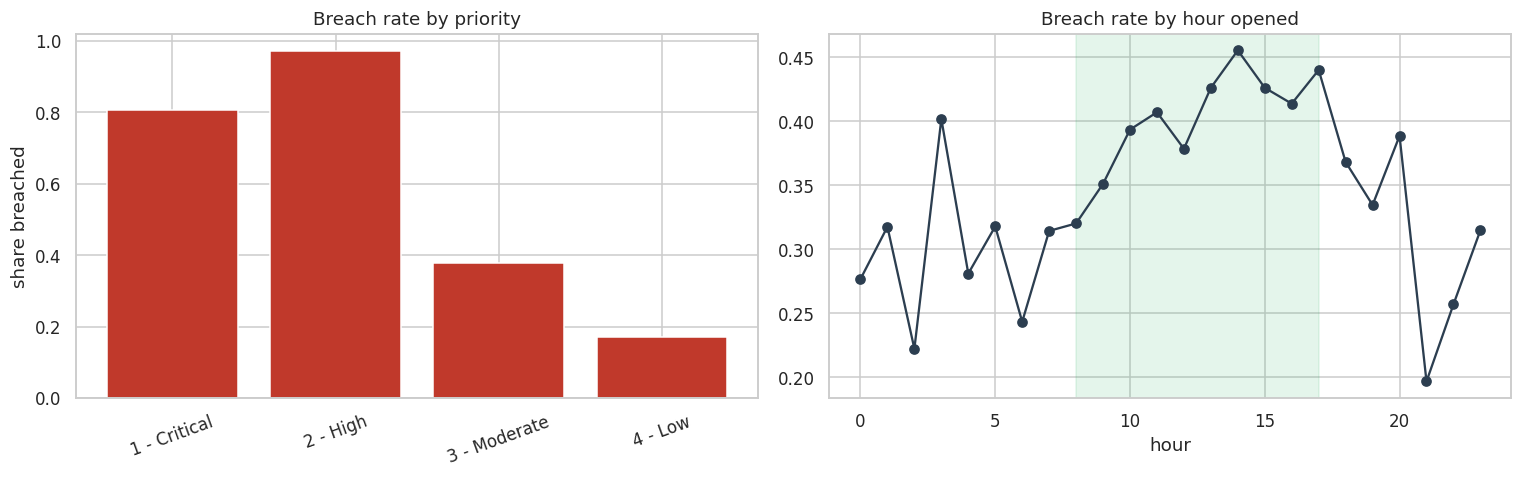

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

by_priority = inc.groupby('priority')['breached'].mean().sort_index()
axes[0].bar(by_priority.index.astype(str), by_priority.values, color='#c0392b')
axes[0].set_title('Breach rate by priority')
axes[0].set_ylabel('share breached')
axes[0].tick_params(axis='x', rotation=20)

by_hour = inc.groupby('open_hour')['breached'].mean()
axes[1].plot(by_hour.index, by_hour.values, marker='o', color='#2c3e50')
axes[1].axvspan(8, 17, alpha=0.12, color='#27ae60')
axes[1].set_title('Breach rate by hour opened')
axes[1].set_xlabel('hour')

plt.tight_layout()
plt.savefig('plots/01_breach_rates.png', bbox_inches='tight')
plt.show()

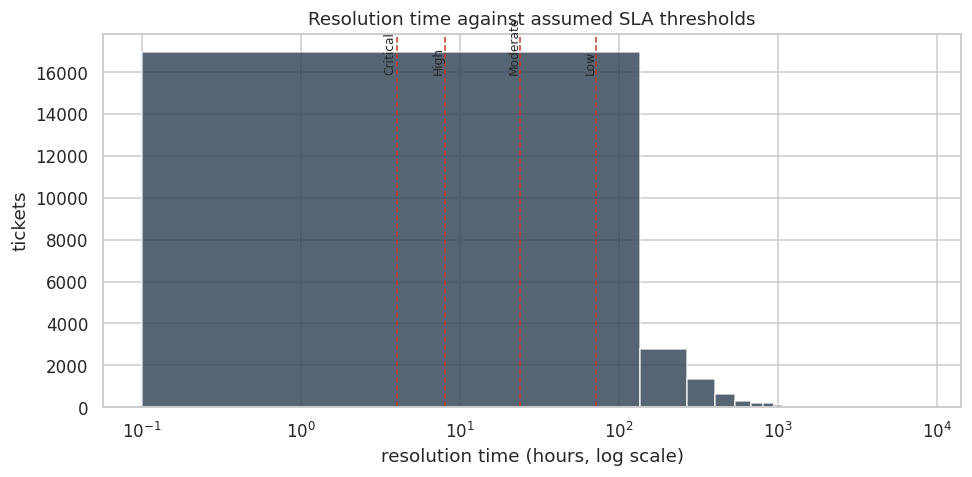

In [18]:
# Resolution time is heavily right-skewed, so plot it on a log axis with the assumed
# SLA thresholds marked. Anything to the right of a line is a derived breach.
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(inc['resolution_hours'].clip(lower=0.1), bins=60, color='#2c3e50', alpha=0.8)
ax.set_xscale('log')
for label, hours in SLA_HOURS.items():
    ax.axvline(hours, ls='--', lw=1, color='#c0392b')
    ax.text(hours, ax.get_ylim()[1] * 0.9, label.split(' - ')[1],
            rotation=90, fontsize=8, ha='right')

ax.set(xlabel='resolution time (hours, log scale)', ylabel='tickets',
       title='Resolution time against assumed SLA thresholds')
plt.tight_layout()
plt.savefig('plots/02_resolution_time.png', bbox_inches='tight')
plt.show()

## 9. Modelling

**On the split.** These tickets are time-ordered. A random split lets a model learn from the
future of the same period, which is not how it would be deployed. Training on earlier tickets
and testing on later ones is the honest version and is used here.

In [19]:
data = data.sort_values('opened_at_final')
cut = int(len(data) * 0.8)
train, test = data.iloc[:cut], data.iloc[cut:]

X_train, y_train = train[FEATURES], train['breached']
X_test, y_test = test[FEATURES], test['breached']

print(f'Train {len(X_train):,} tickets, breach rate {y_train.mean():.1%}, '
      f'{train["opened_at_final"].min().date()} to {train["opened_at_final"].max().date()}')
print(f'Test  {len(X_test):,} tickets, breach rate {y_test.mean():.1%}, '
      f'{test["opened_at_final"].min().date()} to {test["opened_at_final"].max().date()}')

Train 18,689 tickets, breach rate 41.9%, 2016-02-29 to 2016-05-11
Test  4,673 tickets, breach rate 23.6%, 2016-05-11 to 2017-02-16


In [20]:
prep = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
])

def evaluate(name, model, X=None, y=None):
    X = X_test if X is None else X
    y = y_test if y is None else y
    proba = model.predict_proba(X)[:, 1]
    print(f'--- {name} ---')
    print(f'ROC-AUC {roc_auc_score(y, proba):.3f} | '
          f'PR-AUC {average_precision_score(y, proba):.3f} '
          f'(baseline {y.mean():.3f})')
    print(classification_report(y, (proba >= 0.5).astype(int),
                                target_names=['met SLA', 'breached']))
    return proba

scores = {}

In [21]:
# Baseline first. If this cannot beat the base rate by a useful margin, the problem is
# the features, and adding gradient boosting will not rescue it.
logreg = Pipeline([('prep', prep),
                   ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                              random_state=SEED))])
logreg.fit(X_train, y_train)
scores['Logistic regression'] = evaluate('Logistic regression', logreg)

--- Logistic regression ---
ROC-AUC 0.744 | PR-AUC 0.464 (baseline 0.236)
              precision    recall  f1-score   support

     met SLA       0.80      0.95      0.87      3572
    breached       0.56      0.21      0.30      1101

    accuracy                           0.77      4673
   macro avg       0.68      0.58      0.58      4673
weighted avg       0.74      0.77      0.73      4673



In [22]:
rf = Pipeline([('prep', prep),
               ('clf', RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                              class_weight='balanced_subsample',
                                              n_jobs=-1, random_state=SEED))])
rf.fit(X_train, y_train)
scores['Random forest'] = evaluate('Random forest', rf)

hgb = Pipeline([('prep', prep),
                ('clf', HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08,
                                                       random_state=SEED))])
hgb.fit(X_train, y_train)
scores['Gradient boosting'] = evaluate('Gradient boosting', hgb)

BEST, BEST_PROBA = hgb, scores['Gradient boosting']   # revise on PR-AUC, not accuracy

--- Random forest ---
ROC-AUC 0.789 | PR-AUC 0.550 (baseline 0.236)
              precision    recall  f1-score   support

     met SLA       0.84      0.87      0.85      3572
    breached       0.51      0.45      0.48      1101

    accuracy                           0.77      4673
   macro avg       0.68      0.66      0.67      4673
weighted avg       0.76      0.77      0.76      4673

--- Gradient boosting ---
ROC-AUC 0.793 | PR-AUC 0.558 (baseline 0.236)
              precision    recall  f1-score   support

     met SLA       0.81      0.94      0.87      3572
    breached       0.60      0.29      0.39      1101

    accuracy                           0.79      4673
   macro avg       0.71      0.62      0.63      4673
weighted avg       0.76      0.79      0.76      4673



In [23]:
# The leak, made explicit.
# Same model, same split, but handed the fields that only exist after resolution.
# The number this prints is not an achievement. It is the control condition that shows
# what the honest score above is being measured against.
LEAK_NUMERIC = ['reassignment_count_final', 'reopen_count_final', 'sys_mod_count_final']
LEAK_CAT = ['closed_code_final', 'incident_state_final']

leak_data = inc[LEAK_NUMERIC + LEAK_CAT + ['breached', 'opened_at_final']].copy()
leak_data[LEAK_CAT] = leak_data[LEAK_CAT].fillna('Unknown').astype(str)
leak_data = leak_data.sort_values('opened_at_final')

lX_train = leak_data.iloc[:cut][LEAK_NUMERIC + LEAK_CAT]
lX_test = leak_data.iloc[cut:][LEAK_NUMERIC + LEAK_CAT]
ly_train = leak_data.iloc[:cut]['breached']
ly_test = leak_data.iloc[cut:]['breached']

leak_model = Pipeline([
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), LEAK_NUMERIC),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), LEAK_CAT)])),
    ('clf', HistGradientBoostingClassifier(max_iter=300, random_state=SEED))])
leak_model.fit(lX_train, ly_train)

leak_proba = leak_model.predict_proba(lX_test)[:, 1]
print(f'Leaky  ROC-AUC : {roc_auc_score(ly_test, leak_proba):.3f}')
print(f'Honest ROC-AUC : {roc_auc_score(y_test, BEST_PROBA):.3f}')
print('\nThe gap between these two numbers is the finding.')

Leaky  ROC-AUC : 0.931
Honest ROC-AUC : 0.793

The gap between these two numbers is the finding.


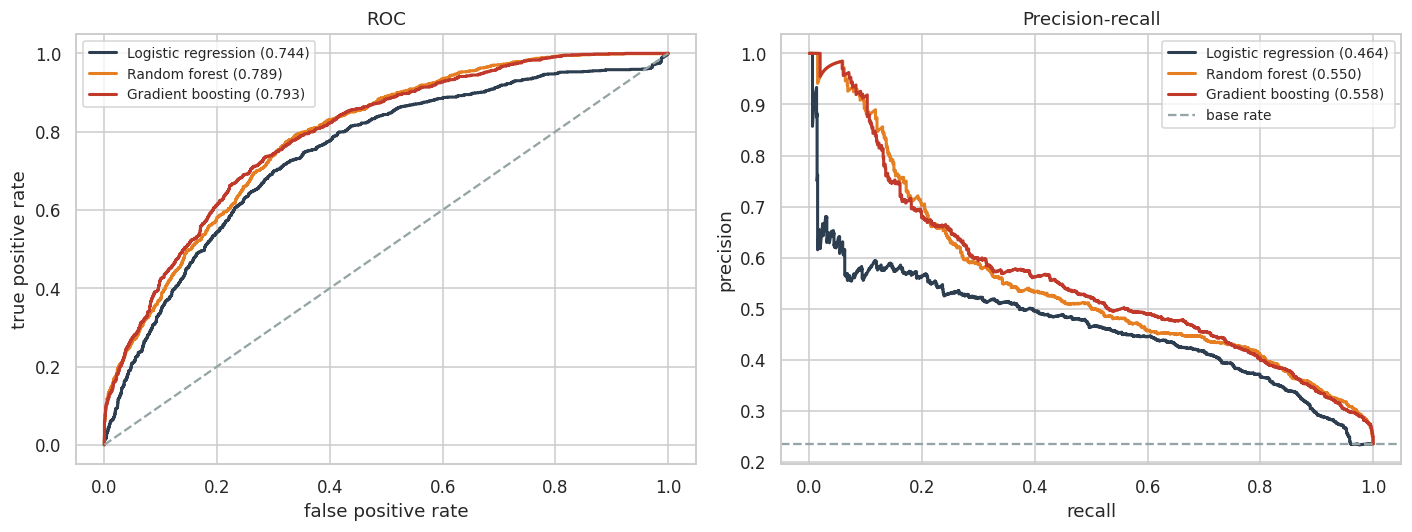

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for (name, proba), colour in zip(scores.items(), ['#2c3e50', '#e67e22', '#c0392b']):
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=colour, lw=2,
                 label=f'{name} ({roc_auc_score(y_test, proba):.3f})')
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, color=colour, lw=2,
                 label=f'{name} ({average_precision_score(y_test, proba):.3f})')

axes[0].plot([0, 1], [0, 1], '--', color='#95a5a6')
axes[0].set(title='ROC', xlabel='false positive rate', ylabel='true positive rate')
axes[1].axhline(y_test.mean(), ls='--', color='#95a5a6', label='base rate')
axes[1].set(title='Precision-recall', xlabel='recall', ylabel='precision')
for ax in axes:
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plots/03_model_curves.png', bbox_inches='tight')
plt.show()

## 10. Where to Set the Threshold

0.5 is a default, not a decision. The real trade-off:

- a **missed breach** means the ticket blows its SLA with nobody warned
- a **false alarm** costs an agent a few minutes, and enough of them get the flag ignored

Pick a cost ratio, defend it in one line, then let it choose the threshold.

In [25]:
COST_FN, COST_FP = 10, 1   # assumption — justify it in the write-up

grid = np.linspace(0.05, 0.95, 91)
cost, recall, precision = [], [], []

for t in grid:
    tn, fp, fn, tp = confusion_matrix(y_test, (BEST_PROBA >= t).astype(int)).ravel()
    cost.append(fn * COST_FN + fp * COST_FP)
    recall.append(tp / (tp + fn) if tp + fn else 0)
    precision.append(tp / (tp + fp) if tp + fp else 0)

i = int(np.argmin(cost))
best_t = grid[i]
default_i = int(np.argmin(np.abs(grid - 0.5)))

print(f'Optimal threshold {best_t:.2f}')
print(f'  catches {recall[i]:.1%} of breaches, {precision[i]:.1%} of flags are real')
print(f'  cost {cost[i]:,.0f} vs {cost[default_i]:,.0f} at the 0.50 default '
      f'({1 - cost[i] / cost[default_i]:.0%} lower)')

Optimal threshold 0.08
  catches 97.5% of breaches, 29.1% of flags are real
  cost 2,891 vs 7,996 at the 0.50 default (64% lower)


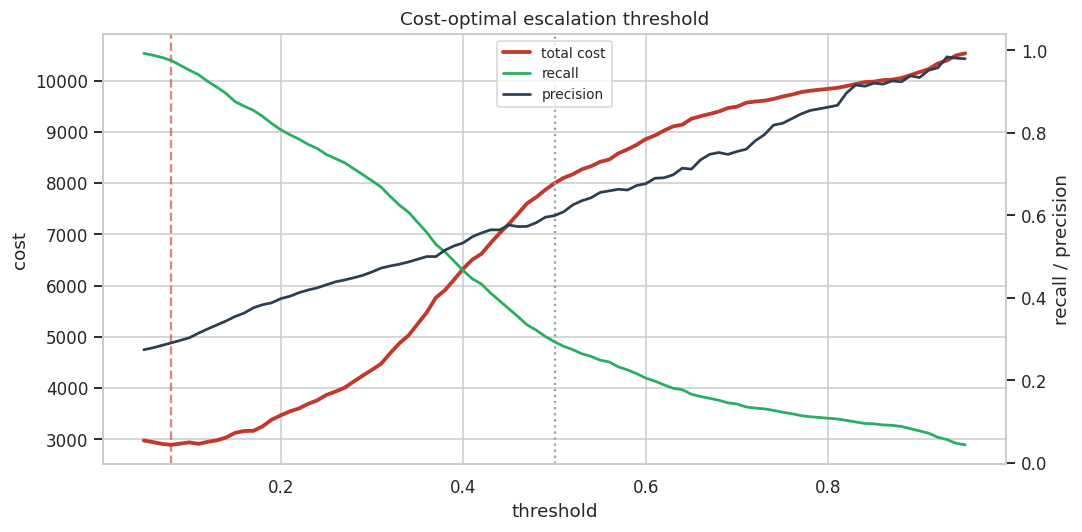

In [26]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(grid, cost, color='#c0392b', lw=2.5, label='total cost')
ax1.axvline(best_t, ls='--', color='#c0392b', alpha=0.6)
ax1.axvline(0.5, ls=':', color='#95a5a6')
ax1.set(xlabel='threshold', ylabel='cost', title='Cost-optimal escalation threshold')

ax2 = ax1.twinx()
ax2.plot(grid, recall, color='#27ae60', lw=1.8, label='recall')
ax2.plot(grid, precision, color='#2c3e50', lw=1.8, label='precision')
ax2.set_ylabel('recall / precision')
ax2.grid(False)

lines = ax1.get_lines()[:1] + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='upper center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/04_threshold.png', bbox_inches='tight')
plt.show()

## 11. What Drives a Breach

Permutation importance is computed on held-out data and works for any model, unlike tree
importances which inflate high-cardinality columns.

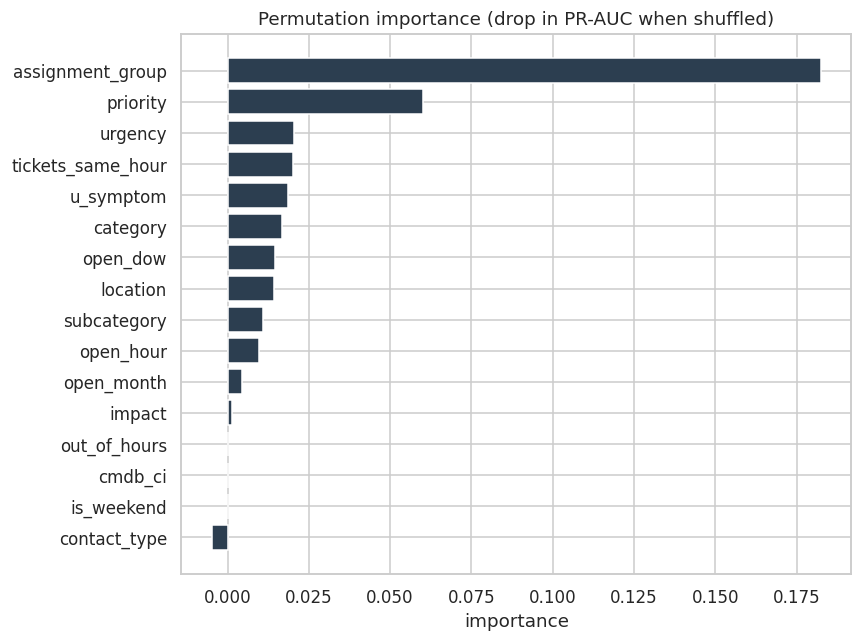

,0
assignment_group,0.182466
priority,0.060238
urgency,0.020292
tickets_same_hour,0.020002
u_symptom,0.018731
category,0.016721
open_dow,0.014706
location,0.014223
subcategory,0.010812
open_hour,0.009709


In [27]:
perm = permutation_importance(BEST, X_test, y_test, scoring='average_precision',
                              n_repeats=10, random_state=SEED, n_jobs=-1)

importance = pd.Series(perm.importances_mean, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance.index, importance.values, color='#2c3e50')
ax.set(title='Permutation importance (drop in PR-AUC when shuffled)', xlabel='importance')
plt.tight_layout()
plt.savefig('plots/05_importance.png', bbox_inches='tight')
plt.show()

importance.sort_values(ascending=False).head(10)

In [28]:
# Direction check on the strongest feature. If it matters to the model but the pattern
# makes no operational sense, that is either a leak that survived Section 6 or a data
# quirk worth a paragraph in the write-up.
top = importance.idxmax()
print(f'Breach rate across levels of "{top}":')
inc.groupby(data[top] if top in CATEGORICAL else inc[top])['breached'].agg(['mean', 'size'])

Breach rate across levels of "assignment_group":


,mean,size
assignment_group,,
Group 10,0.746951,328
Group 20,0.507559,1389
Group 22,0.508591,291
Group 23,0.256849,292
Group 24,0.294693,716
Group 25,0.528231,797
Group 27,0.395425,306
Group 28,0.522152,316
Group 29,0.597656,256


## 12. Output

In [29]:
out = test[['number', 'priority', 'category', 'assignment_group']].copy()
out['breach_probability'] = BEST_PROBA.round(3)
out['flagged'] = (BEST_PROBA >= best_t).astype(int)
out['actual'] = y_test.values
out['risk_band'] = pd.cut(BEST_PROBA, [0, .25, .50, .75, 1.0],
                          labels=['Low', 'Medium', 'High', 'Critical'])

out = out.sort_values('breach_probability', ascending=False)
out.to_csv('sla_risk_scores.csv', index=False)

print(f'{len(out):,} tickets scored, {out["flagged"].sum():,} flagged '
      f'({out["flagged"].mean():.1%} of volume)')
out.head(10)

4,673 tickets scored, 3,695 flagged (79.1% of volume)


,number,priority,category,assignment_group,breach_probability,flagged,actual,risk_band
22190,INC0031099,2 - High,Category 53,Group 29,0.995,1,1,Critical
22112,INC0030999,2 - High,Category 46,Group 22,0.992,1,1,Critical
22147,INC0031046,2 - High,Category 19,Group 72,0.992,1,1,Critical
23499,INC0032824,2 - High,Category 24,Group 72,0.992,1,1,Critical
22658,INC0031735,2 - High,Category 42,Group 55,0.991,1,1,Critical
22694,INC0031780,2 - High,Category 46,Other,0.991,1,1,Critical
23008,INC0032183,2 - High,Category 53,Group 20,0.991,1,1,Critical
23762,INC0033199,2 - High,Category 46,Group 57,0.990,1,1,Critical
20880,INC0029379,2 - High,Category 57,Other,0.990,1,1,Critical
23432,INC0032733,2 - High,Category 23,Group 20,0.989,1,1,Critical


In [30]:
# Does the risk banding hold up against what actually happened?
(out.groupby('risk_band', observed=True)
    .agg(tickets=('number', 'count'), actual_breach_rate=('actual', 'mean'))
    .assign(actual_breach_rate=lambda d: (d['actual_breach_rate'] * 100).round(1)))

,tickets,actual_breach_rate
risk_band,,
Low,2766,10.1
Medium,1368,36.5
High,375,50.1
Critical,164,82.3


## 13. Findings

*Written once the numbers are real.*

1. Overall breach rate is X%, concentrated in ...
2. A leakage-free model reaches PR-AUC X against a base rate of Y.
3. The same model given post-resolution fields reaches Z. That gap separates prediction
   from hindsight and explains why published results on this dataset run so high.
4. The strongest intake-time signal is ..., which points at ... as an operational cause.

**Recommended actions**

| Band | Action |
|---|---|
| Critical | escalate at intake, second responder assigned |
| High | flagged in the queue view, reviewed at standup |
| Medium / Low | no action |

**Limitations**

- One company, one 2016 window. The model would need retraining elsewhere.
- The first audit event approximates intake but is not intake itself.
- Derived SLA thresholds are assumed, not contractual.
- Acting on a flag changes the outcome, so a deployed version degrades without retraining
  on post-intervention data.

**A note on a weak result.** If the honest model lands only modestly above the base rate,
that is the finding, and it is worth reporting as one. Intake-time fields may simply not
carry much information about what happens over the following days. State that, show the
evidence, and describe what the desk would need to capture to do better.